## PRAICP-1012-Pneumonia chest x-ray classification

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

### STEP 1: Understand Dataset Structure

In [2]:
!ls /kaggle/input

chest-xray-dataset


In [3]:
!ls /kaggle/input/chest-xray-dataset

Chest-Xray-2


In [4]:
!ls /kaggle/input/chest-xray-dataset/Chest-Xray-2

chest_xray


In [5]:
!ls /kaggle/input/chest-xray-dataset/Chest-Xray-2/chest_xray

test  train  val


In [6]:
!ls /kaggle/input/chest-xray-dataset/Chest-Xray-2/chest_xray/train

NORMAL	PNEUMONIA


### STEP 2: Define Dataset Paths
- Avoid hardcoding paths

- Makes code reusable & readable

In [7]:
BASE_DIR = "/kaggle/input/chest-xray-dataset/Chest-Xray-2/chest_xray"

TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR  = os.path.join(BASE_DIR, "test")
VAL_DIR   = os.path.join(BASE_DIR, "val")

### STEP 3: Count Images
#### What you should notice
- Train set is large
- Validation set is small
- Test set is separate

This avoids data leakage

In [8]:
def count_images(folder):
    total = 0
    for sub in os.listdir(folder):
        sub_path = os.path.join(folder, sub)
        if os.path.isdir(sub_path):
            total += len(os.listdir(sub_path))
    return total

print("Train images:", count_images(TRAIN_DIR))
print("Val images:", count_images(VAL_DIR))
print("Test images:", count_images(TEST_DIR))

Train images: 5216
Val images: 16
Test images: 624


#### We observed that is val_data is only16 images:
Why 16 Validation Images Is a Problem

- Validation accuracy becomes unstable

- Loss curve is meaningless

- EarlyStopping cannot be trusted

- One wrong prediction = 6.25% accuracy change

- Model may look “perfect” but actually overfit

In real ML work, this is not acceptable.

### STEP 4: Data Preprocessing & Augmentation

### Use validation_split in ImageDataGenerator

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_val_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

2026-02-02 06:42:14.193874: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770014534.533770      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770014534.628305      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770014535.404043      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770014535.404128      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770014535.404131      55 computation_placer.cc:177] computation placer alr

### STEP 5: Load Images Using Generators

#### Training Generator

In [10]:
train_gen = train_val_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(224,224),
    batch_size=32,
    class_mode="binary",
    subset="training"
)

Found 4173 images belonging to 2 classes.


#### Validation Generator (New, Proper size)
##### Create new validation set:
“The provided validation set was extremely small, so I merged it with the training data and created a new validation split using ImageDataGenerator to obtain a statistically meaningful validation set.”

In [11]:
val_gen = train_val_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(224,224),
    batch_size=32,
    class_mode="binary",
    subset="validation"
)

Found 1043 images belonging to 2 classes.


In [12]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(224,224),
    batch_size=32,
    class_mode="binary",
    shuffle=False
)

Found 624 images belonging to 2 classes.


and preserved the test set for unbiased evaluation.

#### Verify Counts After Splitting

In [13]:
print("Train:", train_gen.samples)
print("Val:", val_gen.samples)
print("Test:", test_gen.samples)

Train: 4173
Val: 1043
Test: 624


### STEP 6: Verify Class Mapping
CRITICAL things happening here

- Images → tensors

- Labels auto-assigned

shuffle=False for test → needed for evaluation

In [14]:
train_gen.class_indices

{'NORMAL': 0, 'PNEUMONIA': 1}

### Plot Sample Images

#### Get One Batch from Generator

In this :

images → shape (batch_size, 224, 224, 3)

labels → 0 or 1

In [15]:
images, labels = next(train_gen)

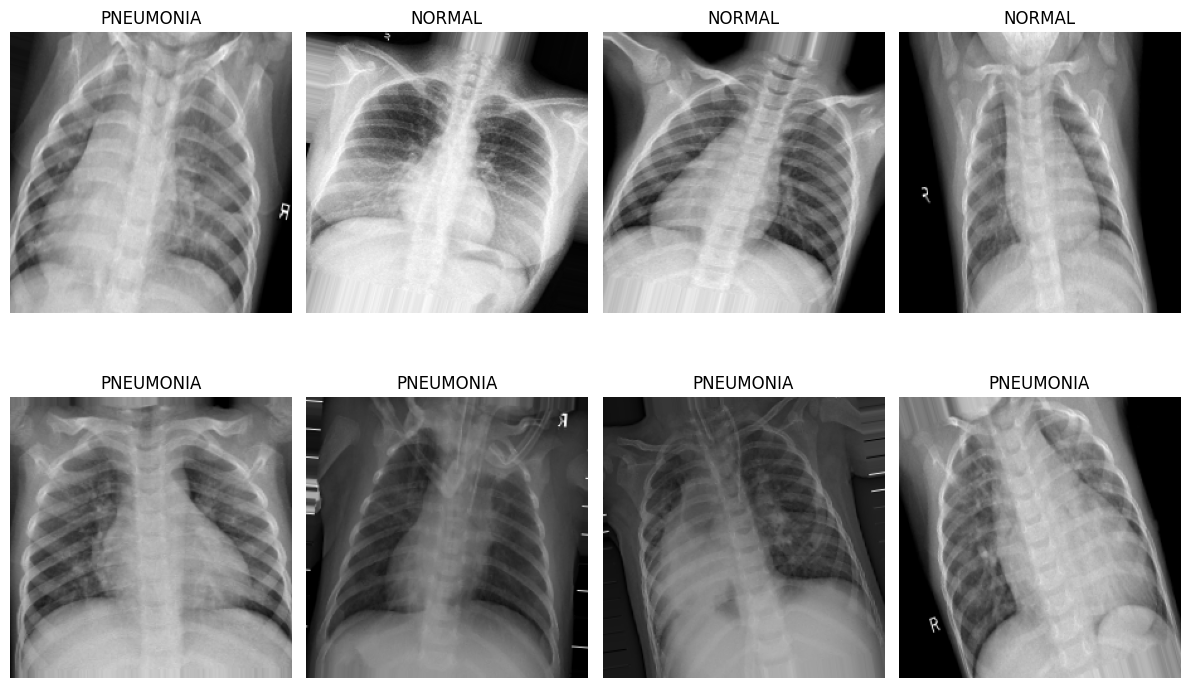

In [16]:
plt.figure(figsize=(12, 8))

for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.imshow(images[i])
    plt.title("NORMAL" if labels[i] == 0 else "PNEUMONIA")
    plt.axis("off")

plt.tight_layout()
plt.show()

### What You Should Observe
#### NORMAL X-rays:

- Clear lung fields
- Less white opacity
- Uniform texture

#### PNEUMONIA X-rays:

- White patches (infiltrates)
- Cloudy lung regions
- Reduced contrast

This confirms visual separability of clas

## STEP 7: Build Transfer Learning Model (MobileNetV2)
#### Why MobileNetV2?

- Lightweight and Faster

- Strong baseline for medical images

In [17]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model

In [18]:
# Load Pretrained Base Model
base_model = tf.keras.applications.MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False  # freeze

2026-02-02 06:43:36.683575: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [19]:
# Add Custom Classification Head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)

### STEP 8: Compile Model
In this why binary_crossentropy?

- Two classes---Sigmoid output---Medical binary classification

In [20]:
# Compile Model

model.compile(
    optimizer="adam",  
    loss='binary_crossentropy',
    metrics=['accuracy']
)

### STEP 9: Train Model

In [21]:
# Add Callbacks (VERY IMPORTANT)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_fine = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)

Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 237s 2s/step - accuracy: 0.8580 - loss: 0.3387 - val_accuracy: 0.9367 - val_loss: 0.1499
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 194s 1s/step - accuracy: 0.9377 - loss: 0.1465 - val_accuracy: 0.9444 - val_loss: 0.1293
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 192s 1s/step - accuracy: 0.9404 - loss: 0.1402 - val_accuracy: 0.9607 - val_loss: 0.1111
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 195s 1s/step - accuracy: 0.9497 - loss: 0.1245 - val_accuracy: 0.9473 - val_loss: 0.1308
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 194s 1s/step - accuracy: 0.9561 - loss: 0.1176 - val_accuracy: 0.9607 - val_loss: 0.0992
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 199s 2s/step - accuracy: 0.9540 - loss: 0.1110 - val_accuracy: 0.9501 - val_loss: 0.1201
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 194s 1s/step - accuracy: 0.9540 - loss: 0.1201 - val_accuracy: 0.9521 - val_loss: 0.1215
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 195s 1s/step - accuracy: 0.9562 - loss: 0.1219 - val_accu

### STEP 10: Save Model

In [22]:
model.save("/kaggle/working/best_pneumonia_model3.keras")

In [23]:
from tensorflow.keras.models import load_model
model = load_model("best_pneumonia_model3.keras")

In [24]:
!ls /kaggle/working

best_pneumonia_model3.keras


### STEP 11: Evaluate on Test Data

In [25]:
# Evaluate on Test Data
loss, acc = model.evaluate(test_gen)
print(f"Test Accuracy: {acc:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 883ms/step - accuracy: 0.8708 - loss: 0.3331
Test Accuracy: 0.9022


### STEP 12: Predictions for Evaluation

In [26]:
# Predict probabilities
y_prob = model.predict(test_gen)

# Convert probabilities → class labels (0 or 1)
y_pred = (y_prob > 0.5).astype(int).ravel()

# True labels
y_true = test_gen.classes

20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 904ms/step


### STEP 13: Confusion Matrix & Report
Main obsevasion thing is:

- Recall for Pneumonia

- False Negatives are dangerous

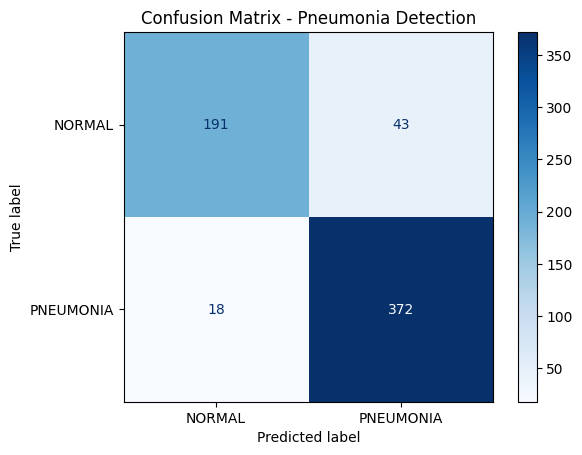

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["NORMAL", "PNEUMONIA"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Pneumonia Detection")
plt.show()

### Classification Report

In [28]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=["NORMAL", "PNEUMONIA"]
))

              precision    recall  f1-score   support

      NORMAL       0.91      0.82      0.86       234
   PNEUMONIA       0.90      0.95      0.92       390

    accuracy                           0.90       624
   macro avg       0.91      0.89      0.89       624
weighted avg       0.90      0.90      0.90       624



### STEP 14: Misclassified Images Analysis


In [29]:
misclassified_idx = np.where(y_true != y_pred)[0]
print("Total misclassified images:", len(misclassified_idx))

Total misclassified images: 61


In [33]:
file_paths = test_gen.filepaths

#### Plot Misclassified Images

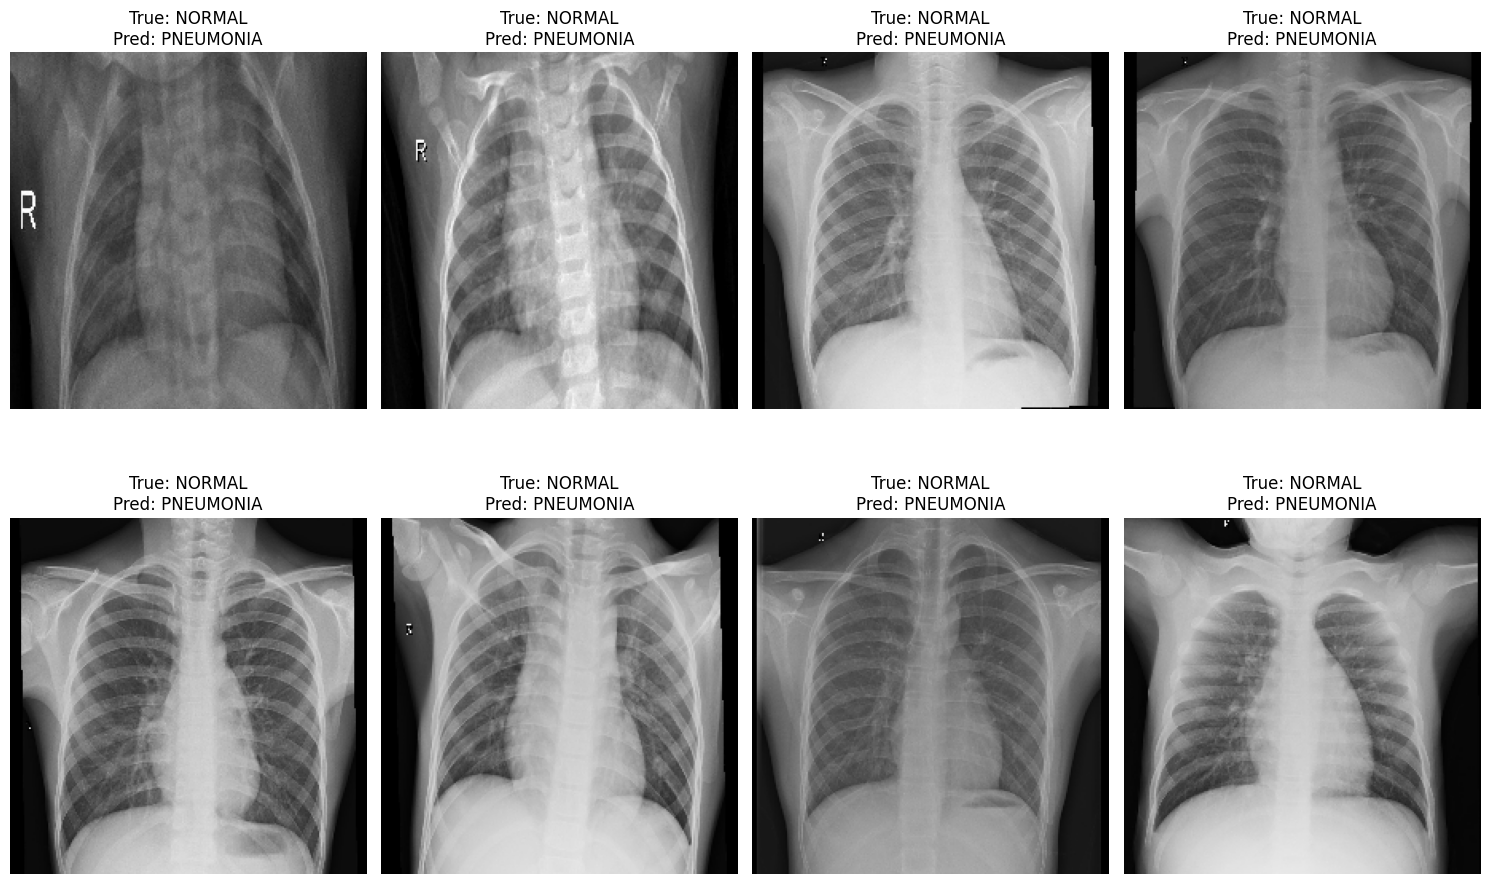

In [34]:
import tensorflow as tf

plt.figure(figsize=(15, 10))

for i, idx in enumerate(misclassified_idx[:8]):  # show first 8
    img = tf.keras.preprocessing.image.load_img(
        file_paths[idx],
        target_size=(224,224)
    )
    
    plt.subplot(2, 4, i+1)
    plt.imshow(img)
    
    true_label = "NORMAL" if y_true[idx] == 0 else "PNEUMONIA"
    pred_label = "NORMAL" if y_pred[idx] == 0 else "PNEUMONIA"
    
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### STEP 15: Plot Accuracy & Loss Curves

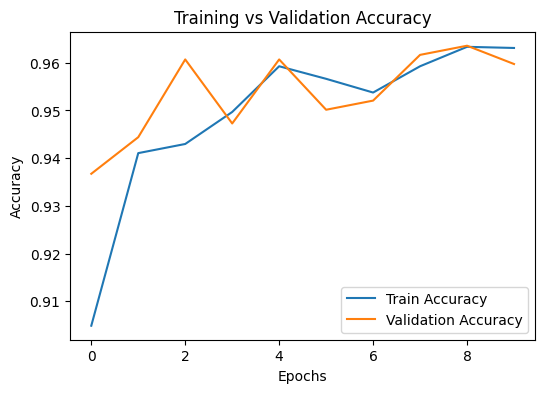

In [36]:
plt.figure(figsize=(6,4))
plt.plot(history_fine.history['accuracy'], label='Train Accuracy')
plt.plot(history_fine.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

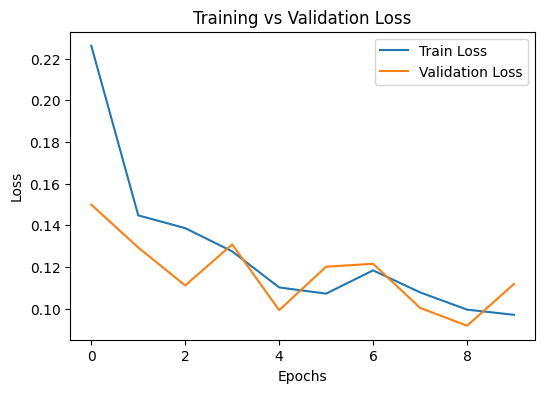

In [37]:
plt.figure(figsize=(6,4))
plt.plot(history_fine.history['loss'], label='Train Loss')
plt.plot(history_fine.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

## Conclusion:
- Built a CNN-based Pneumonia detection system using Chest X-ray images achieving 90% accuracy and 95% recall for pneumonia, minimizing false negatives in a medical diagnosis setting.